# Height and heritability

Height is strongly heritable, yet average height can change when living conditions change. How can both statements be true?

## Start from first principles

For person $i$, write

$$
Y_i=\mu+A_i+E_i,
$$

where $A_i$ is the additive genetic deviation and $E_i$ is the environmental and random deviation. If the two deviations are independent,

$$
V_P=V_A+V_E,
\qquad
h^2=\frac{V_A}{V_P}.
$$

More generally, $V_G=V_A+V_D+V_I$ can include additive, dominance, and interaction variance. Then

$$
H^2=\frac{V_G}{V_P}
\qquad\text{and}\qquad
h^2=\frac{V_A}{V_P}.
$$

The simulation below isolates additive variance, so its target is narrow-sense heritability $h^2$.

Heritability describes **variation among people in one population and environment**. The population mean $\mu$ is a separate quantity. Changing $\mu$ need not change $V_A$, and changing environmental variance can change $h^2$ even when the genetic effects stay fixed.

## A small model for human height

We simulate three populations under the same additive genetic model,

$$
A_i\sim N(0,V_A),
\qquad
E_i\sim N(0,V_E),
\qquad
Y_i=\mu+A_i+E_i.
$$

The first two populations have the same genetic and environmental variances but different means. The third keeps the second mean and genetic variance but has more environmental variation.

Before running the calculation, we expect:

1. moving $\mu$ will move average height without changing $h^2$;
2. increasing $V_E$ will lower $h^2$ without changing $V_A$; and
3. even when $h^2$ is high, people with the same genetic value can have different phenotypes.

In [1]:
set.seed(8149)

n_people <- 6000

population_parameters <- data.frame(
  population = c("Population A", "Population B", "Population C"),
  mean_height = c(170, 175, 175),
  additive_variance = c(36, 36, 36),
  environmental_variance = c(16, 16, 36)
)

simulate_height <- function(label, mean_height, additive_variance,
                            environmental_variance, n) {
  additive_value <- rnorm(n, 0, sqrt(additive_variance))
  environmental_deviation <- rnorm(n, 0, sqrt(environmental_variance))

  data.frame(
    population = label,
    genetic_value = additive_value,
    environmental_deviation = environmental_deviation,
    height = mean_height + additive_value + environmental_deviation
  )
}

height_data <- do.call(
  rbind,
  lapply(seq_len(nrow(population_parameters)), function(i) {
    with(
      population_parameters[i, ],
      simulate_height(
        population,
        mean_height,
        additive_variance,
        environmental_variance,
        n_people
      )
    )
  })
)

population_list <- split(height_data, height_data$population)

height_summary <- do.call(rbind, lapply(names(population_list), function(label) {
  current <- population_list[[label]]
  parameter_row <- population_parameters[
    population_parameters$population == label,
  ]

  data.frame(
    population = label,
    mean_height = mean(current$height),
    estimated_V_A = var(current$genetic_value),
    estimated_V_P = var(current$height),
    estimated_h2 = var(current$genetic_value) / var(current$height),
    expected_h2 = with(
      parameter_row,
      additive_variance / (additive_variance + environmental_variance)
    )
  )
}))

height_summary

population,mean_height,estimated_V_A,estimated_V_P,estimated_h2,expected_h2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Population A,170.0060,37.06915,51.63644,0.7178874,0.6923077
Population B,174.8886,37.08126,53.66468,0.6909807,0.6923077
Population C,175.1187,36.17937,72.49049,0.4990913,0.5000000


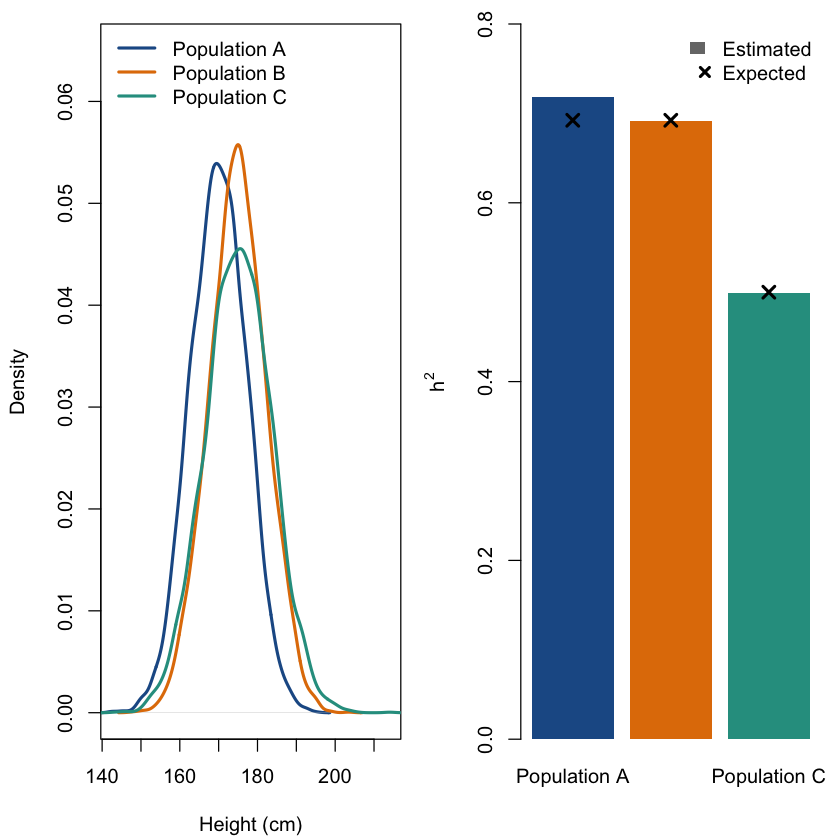

In [2]:
colors <- c("#1F5A94", "#E17C05", "#2A9D8F")
old_par <- par(mfrow = c(1, 2), mar = c(4.2, 4.2, 1.0, 0.8))

height_range <- range(height_data$height)
first_density <- density(population_list[[1]]$height)

plot(
  first_density,
  xlim = height_range,
  ylim = c(0, 0.065),
  lwd = 2.5,
  col = colors[1],
  xlab = "Height (cm)",
  ylab = "Density",
  main = ""
)

for (i in 2:3) {
  lines(
    density(population_list[[i]]$height),
    lwd = 2.5,
    col = colors[i]
  )
}

legend(
  "topleft",
  legend = names(population_list),
  col = colors,
  lwd = 2.5,
  bty = "n"
)

bar_position <- barplot(
  height_summary$estimated_h2,
  names.arg = height_summary$population,
  ylim = c(0, 0.8),
  col = colors,
  border = NA,
  ylab = expression(h^2)
)
points(
  bar_position,
  height_summary$expected_h2,
  pch = 4,
  lwd = 2.5,
  cex = 1.3
)
legend(
  "topright",
  legend = c("Estimated", "Expected"),
  fill = c("#777777", NA),
  border = c(NA, NA),
  pch = c(NA, 4),
  pt.lwd = 2.5,
  bty = "n"
)

par(old_par)

stopifnot(abs(height_summary$mean_height[1] - 170) < 0.5)
stopifnot(abs(height_summary$mean_height[2] - 175) < 0.5)
stopifnot(max(abs(
  height_summary$estimated_h2 - height_summary$expected_h2
)) < 0.04)

## What the example shows

Populations A and B have nearly the same heritability even though their mean heights differ. Population C has the same mean and the same additive genetic variance as Population B, but its larger environmental variance lowers heritability.

The model also separates heritability from individual prediction. Knowing $h^2$ tells us how variance is partitioned in the population. It does not give a person's genetic value, environmental history, or future phenotype.

The simple model leaves out dominance, gene-by-gene interaction, genotype-environment interaction, assortative mating, and measurement error. Those terms can change the variance decomposition or the design needed to estimate it.

## What to remember

- **Concept and intuition.** Heritability is a ratio of variances within a population. It does not describe the origin of one person's phenotype.
- **Insight behind the model.** Separate the population mean from the sources of variation around that mean.
- **Worked example.** A mean shift left $h^2$ unchanged, while additional environmental variance lowered it.

## Sources

- Pritchard, *An Owner's Guide to the Human Genome*, Chapter 4.4, especially the quantitative-trait model and the discussion of changing mean height. [Book page](https://web.stanford.edu/group/pritchardlab/HGbook.html)
- Visscher, Hill, and Wray (2008), *Heritability in the genomics era: concepts and misconceptions*. [DOI](https://doi.org/10.1038/nrg2322)
- The simulation is an original course example. It uses 6,000 people per population, $V_A=36$, $V_E\in\{16,36\}$, and seed 8149.